In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_excel("rest.xlsx", sheet_name="Sheet1")

In [4]:
y = df['annual_premium_amount'].copy()
x = df.drop(['annual_premium_amount'], axis = 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=10, random_state=2)

In [5]:
x_train.head()

,age,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,insurance_plan,diabetes,heart_disease,high_blood_pressure,thyroid,age_bins,income_bins
29268,42,Unmarried,1,Underweight,Regular,Self-Employed,39,Silver,1,0,0,0,2,2
27536,59,Married,4,Obesity,No Smoking,Self-Employed,3,Silver,0,0,0,1,3,1
1157,45,Married,5,Underweight,Occasional,Freelancer,7,Bronze,0,0,0,0,2,1
19399,35,Unmarried,1,Overweight,No Smoking,Freelancer,17,Silver,1,0,1,0,2,2
23789,51,Married,3,Obesity,No Smoking,Salaried,2,Silver,0,0,0,1,3,1


In [46]:
oe = OrdinalEncoder(
    categories=[   
        # ['Unmarried', 'Married'],       
        ['Underweight', 'Normal', 'Overweight', 'Obesity'],       
        ['No Smoking', 'Occasional', 'Regular'],
        # ['Freelancer', 'Self-Employed', 'Salaried'],          
        ['Bronze', 'Silver', 'Gold']        
    ]
)

In [ ]:
#scaling not required
num_cols = [
    "age",
    # 'number_of_dependants',
    # 'income_lakhs',
    'diabetes',	
    'heart_disease',
    'high_blood_pressure',
    'thyroid',
    # 'income_bins',
    # 'age_bins'
]

# All remaining columns → ordinal
ordinal_col = [
    # "marital_status",
    "bmi_category",
    "smoking_status",
    # 'employment_status',
    "insurance_plan"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", oe, ordinal_col)
    ]
)

In [48]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", RandomForestRegressor())
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'diabetes',
                                                   'heart_disease',
                                                   'high_blood_pressure',
                                                   'thyroid']),
                                                 ('cat',
                                                  OrdinalEncoder(categories=[['Underweight',
                                                                              'Normal',
                                                                              'Overweight',
                                                                              'Obesity'],
                                                                             ['No '
                                                                              'Smoking',
                                                                              'Occasional',
                                                                              'Regular'],
                                                                             ['Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['bmi_category',
                                                   'smoking_status',
                                                   'insurance_plan'])])),
                ('tree', RandomForestRegressor())])

In [49]:
# r2 score
model.score(x_test, y_test)

0.9991049157421978

<Axes: xlabel='diff_pct', ylabel='Count'>

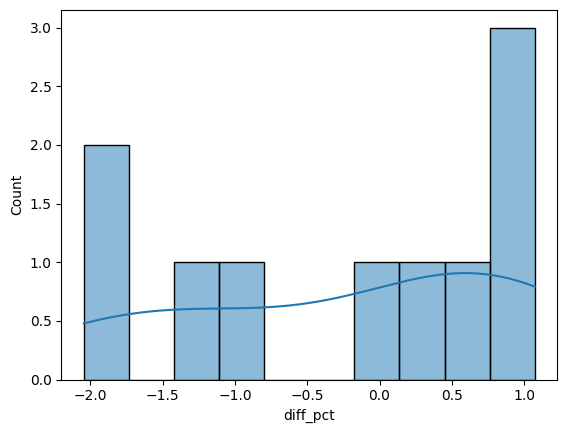

In [50]:
# error analysis
y_pred = model.predict(x_test)
residuals = y_pred - y_test
res_pct = residuals*100 / y_test

results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': res_pct
    })

sns.histplot(results['diff_pct'], bins = 10, kde=True)

In [ ]:
import joblib

joblib.dump(model, 'artifacts/rest_model.pkl')

['artifacts/rest_model.pkl']